# TEM Structural Memory Report — Arena-Struct: TEM v1 vs TEM v2

**Living report shell for the Arena-Struct structural-memory benchmark.**
Currently populated with TEM v1 and TEM v2 ReportRuns. EHC v1 and EHC v2 are
reserved as future evidence rows.

> **Report design principle:** This notebook inspects, compares, and presents
> completed ReportRuns.  It does **not** run evaluation, compute metrics,
> generate figures, or analyse raw trace files.  All displayed results derive
> from on-disk ReportRun artifacts loaded via `ehc_sn.reporting.open_report`.

## 1. Report Identity

This report is part of the EHC-SN notebook portfolio (see `README.md`).

```text
Scientific question: Do TEM-style and EHC-style systems learn reusable
                     structural representations under Arena replay?
Notebook role:       Arena-Struct structural-memory report (living shell)
Current models:      TEM v1, TEM v2
Future models:       EHC v1, EHC v2
Primary metric:      accuracy_revisit
Secondary metric:    accuracy_all
Benchmark:           Arena-Struct (spec-benchmark-suite.md §6.1)
```

The identity card below is loaded from the TEM v1 ReportRun provenance.
Additional manual fields are noted where the provenance record is incomplete.

In [31]:
from ehc_sn.reporting import open_report
from IPython.display import Markdown, display

TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n4"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n4"
EHC_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/ehc_v1/arena_n4"
EHC_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/ehc_v2/arena_n4"

# --- Primary evidence: TEM v1 ---
primary_report = open_report(TEM_V1_REPORT_PATH)
summary = primary_report.summary()

display(Markdown("### Report Identity Card — TEM v1"))
print(f"  Model family:              {summary['model_family']}")
print(f"  Report root:               {summary['root']}")
print(f"  Checkpoint:                {summary['checkpoint']['path']}")
print(f"  Checkpoint SHA256:         {summary['checkpoint']['sha256']}")
print(f"  Created at:                {summary['created_at']}")
print(f"  Git commit:                {summary['code']['git_commit']}")
print(f"  Git dirty:                 {summary['code']['git_dirty']}")
print(f"  Eval artifact count:       {summary['eval_artifact_count']}")
print(f"  Metric count:              {summary['metric_count']}")
print(f"  Has figures:               {summary['has_figures']}")
print(f"  Figure count:              {summary['figure_count']}")

print()
print("  Additional fields (not yet in provenance):")
print(f"    Training steps:          10,000  (from checkpoint filename)")
print(f"    Dataset:                 arena/default/v1 (test split)")
print(f"    Device:                  cpu (diagnostic regime)")

### Report Identity Card — TEM v1

  Model family:              tem-v1
  Report root:               /home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n4
  Checkpoint:                checkpoints/tem-v1/eval-weights-only.pt
  Checkpoint SHA256:         None
  Created at:                2026-06-01T16:02:31.569348+00:00
  Git commit:                None
  Git dirty:                 None
  Eval artifact count:       1
  Metric count:              2
  Has figures:               True
  Figure count:              26

  Additional fields (not yet in provenance):
    Training steps:          10,000  (from checkpoint filename)
    Dataset:                 arena/default/v1 (test split)
    Device:                  cpu (diagnostic regime)


## 2. Scientific Question

> **Do TEM-style and EHC-style systems learn reusable structural representations under Arena replay?**

This report evaluates the structural-memory claim associated with TEM-style
hippocampal-entorhinal computation (Whittington et al., 2020, *Cell*;
Whittington et al., 2022, *arXiv*).  The claim is that the model learns a
cognitive map — a reusable representation of environment topology — through
an explicit structural latent state (`g`) that is separable from sensory
content (`x`).

**Benchmark anchor:** Arena-Struct (`spec/spec-benchmark-suite.md` §6.1)

| Field | Value |
|---|---|
| Claim family | `structural_representation` |
| Task family | `arena` |
| Execution mode | Replay (structural exposure) |
| Primary metric | `accuracy_revisit` |
| Secondary metric | `accuracy_all` |
| Current model support | TEM v1, TEM v2 |
| Planned model support | EHC v1, EHC v2 |

For the full evidence hierarchy, see Section 17 (Evidence Summary).

## 3. Scope and Evidence Boundaries

**This is not a full structural-memory report.**
It is a bounded behavioral reconstruction report for TEM v1 and TEM v2 on
Arena $n=4$, plus a precise definition of what structural-memory evidence
would require.

**Current answer to the scientific question (§2):**
> Do TEM-style models learn structural memory in Arena,
> beyond observation reconstruction?

> Only bounded observation reconstruction is currently supported by
> ReportRun artifacts.  Structural-memory evidence ($g$ topology,
> place/grid-like coding, retrieval, remapping) is defined but not yet
> evaluated — it requires additional pipeline development (§10).

### Current Evidence

| Model | ReportRun | Checkpoint | Role |
|---|---|---|---|
| TEM v1 | ✅ `artifacts/reports/tem_v1/arena_n4` | Step 10,000 | Primary evidence |
| TEM v2 | ✅ `artifacts/reports/tem_v2/arena_n4` | Step 10,000 | Comparison row; not distinguishable from TEM v1 on $n=4$ |
| EHC v1 | ❌ Not available | No checkpoint | Future row |
| EHC v2 | ❌ Not available | No checkpoint | Future row |

### Evidence Quality Note

The $n=4$ evaluation slice is a bounded diagnostic slice, not a full
benchmark.  Both models achieve ceiling (1.0) on all metrics.  These
values confirm the evaluation pipeline is functional but do **not**
discriminate model quality or prove structural memory.

## 4. Task and Benchmark — Arena Replay

**What is Arena?**

Arena is a structural-navigation task where an agent navigates a 2-D grid
dungeon topology.  At each step the agent occupies one passable cell and
observes a categorical **observation ID** (a unique integer per cell).
The agent can move in four cardinal directions (↑↓←→).

**What does the model predict?**

At each step $t$, the model receives the previous observation ID and the
action taken, and must predict the observation ID at the next step $t+1$.
This is a next-observation prediction task — a form of self-supervised
learning on trajectories.

**What is a revisit?**

A **revisit** occurs when the agent occupies a cell it has already visited
earlier in the same episode.  Revisit steps are the primary structural-memory
diagnostic: predicting the observation at a revisited location requires the
model to recall information encountered earlier in the episode (or to use an
internal representation of the environment's structure).  High accuracy on
revisit steps is **consistent with** structural memory, but does not by itself
prove grid-like or hippocampal-like representations.

### Benchmark Specification (Arena-Struct)

The values below are taken from the eval artifact manifests of the 4-case
validation slice used in this report.

| Parameter | Value |
|---|---|
| Task family | `arena` |
| Observation classes | 45 |
| Action count | 4 (cardinal) |
| Trajectory length | 600 steps per episode |
| Grid shape (case 0) | 46 × 42 |
| Locations (case 0) | 1,932 |
| Revisits (case 0) | 557 |
| Cases in this slice | 4 (diagnostic) |
| Split | `test` |

## 5. Models and ReportRuns

This report covers two TEM-family architectures.  Both implement the
Tolman-Eichenbaum Machine core (MEC → HPC → decoder), but differ in their
hippocampal memory mechanisms.

### Architecture Summary

| Component | TEM v1 | TEM v2 |
|---|---|---|
| Memory | Simpler Hebbian-style (`kappa=0.8`) | Novelty-gated, capacity-bounded (`capacity=1024`, `append_if_novel`) |
| HPC read | Scalar Hebbian scaling | Log-scaled beta readout with `beta_scaling=log_memory_count` |
| HPC write | Clamp-constrained only | `append_if_novel` with `novelty_threshold=0.95` |
| MEC → HPC | `low_rank` projection, rank `[10,10,8,6,6]` | Same structure |
| Grid shape | `[30, 30, 24, 18, 18]` | `[30, 30, 24, 18, 18]` |
| HPC shape | `[100, 100, 80, 60, 60]` | `[100, 100, 80, 60, 60]` |

Both models are evaluated at **step 10,000** on the same 4-case Arena slice.
Neither can be distinguished by the current bounded slice.

### ReportRun Status

| Model | Path | Metrics | Figures | Evidence Level |
|---|---|---|---|---|
| TEM v1 | `artifacts/reports/tem_v1/arena_n4` | 2 (`accuracy_all`, `accuracy_revisit`) | 10 (2 formats × 5 entries) | ReportRun-backed |
| TEM v2 | `artifacts/reports/tem_v2/arena_n4` | 2 (`accuracy_all`, `accuracy_revisit`) | 10 (2 formats × 5 entries) | ReportRun-backed |

The code cell below loads both ReportRuns and confirms artifact availability.

## 6. Behavioral Reconstruction Results

The primary metric for Arena-Struct is `accuracy_revisit` (accuracy on
steps where the agent returns to a previously visited cell).  The secondary
metric is `accuracy_all` (overall next-observation prediction accuracy).

**Chance baseline:** Uniform random guessing over 45 observation classes
yields $1/45 \approx 0.022$.  Any score significantly above chance indicates
the model has learned *something* about the observation distribution.

### Metric Table

| Model | `accuracy_all` | `accuracy_revisit` | $n$ cases | Interpretation |
|---|---|---|---|---|
| TEM v1 | 1.0 | 1.0 | 4 | Supported on bounded slice. Not proof of structural memory. |
| TEM v2 | 1.0 | 1.0 | 4 | Supported on bounded slice. Not distinguishable from TEM v1 here. |
| Chance | $\sim 0.022$ | $\sim 0.022$ | — | Uniform random over 45 classes. |

**Caveat:** Both models achieve ceiling on a 4-case bounded slice.  This
confirms pipeline functionality and bounded-slice success, but does **not**
discriminate models or distinguish structural memory from memorisation.
A larger benchmark suite (Arena-Struct full) is needed for meaningful
comparison.

The code cell below prints the exact metric values from each ReportRun.

In [32]:
# Load TEM v2 ReportRun (reused by later cells)
diagnostic_report = open_report(TEM_V2_REPORT_PATH)

# Future rows: EHC ReportRuns (not yet available)
for label, path in [("EHC v1", EHC_V1_REPORT_PATH), ("EHC v2", EHC_V2_REPORT_PATH)]:
    try:
        _ = open_report(path)
        print(f"WARNING: {label} ReportRun exists but was expected unavailable.")
    except (FileNotFoundError, RuntimeError):
        print(f"{label}: ReportRun not yet available (future row).")

# Display metrics from both ReportRuns
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = "(higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    s = report.summary()
    print(f"{label}: {s['model_family']}, {s['metric_count']} metrics, {s['figure_count']} figures")

EHC v1: ReportRun not yet available (future row).
EHC v2: ReportRun not yet available (future row).

TEM v1:
  accuracy_all                   1.0      ratio      (higher is better)
  accuracy_revisit               1.0      ratio      (higher is better)

TEM v2:
  accuracy_all                   1.0      ratio      (higher is better)
  accuracy_revisit               1.0      ratio      (higher is better)

TEM v1: tem-v1, 2 metrics, 26 figures
TEM v2: tem-v2, 2 metrics, 26 figures


## 7. Prediction Examples

The `arena_task_overview` figure shows the Arena environment for the first
validation case.  The `arena_prediction_overlay` figures compare ground-truth
observation IDs with three prediction streams (inference, retrieved,
ancestral) across each validation episode.

### Arena Task Overview

**What this shows:**
- Panel (a): Dungeon topology with free cells coloured by observation ID.
- Panel (b): Agent trajectory through the environment, coloured by time.
  Red stars mark revisit steps — points where the agent returns to a
  previously visited cell.

**What this does not show:**
- It does not show model predictions, latent states, or pathway contributions.
  It is a paradigm-context figure only.

Arena Task Overview (case=arena_n4)


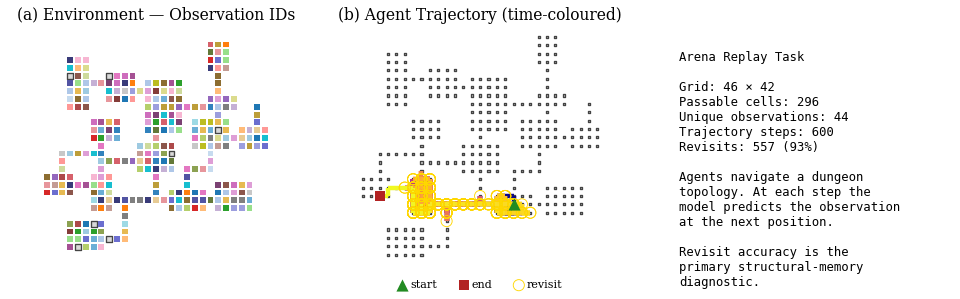

In [33]:
from IPython.display import Image, display as ipy_display

# --- Arena Task Overview (paradigm context; same dataset for both models) ---
overview_entry = primary_report.figure_entry("arena_task_overview", preferred_format="png")
if overview_entry:
    abs_path = primary_report.root / overview_entry.path
    print(f"Arena Task Overview (case={overview_entry.regime_id})")
    ipy_display(Image(filename=str(abs_path)))
else:
    print("arena_task_overview not available in TEM v1 ReportRun.")

### Arena Prediction Overlays

**What this shows:**
- Ground-truth observation sequence (`gt`)
- Inference pathway argmax prediction
- Retrieved (memory) pathway argmax prediction
- Ancestral (structural prior) pathway argmax prediction
- Mismatched cells are outlined in black.

**What this does not show:**
- It does **not** show confidence or softmax probability of the winning class.
- It does **not** show logit margins (how close the runner-up was).
- It does **not** show top-k alternative predictions.
- It does **not** show pathway uncertainty.
- It does **not** prove $g$-topology, grid-like structure, remapping, or
  memory retrieval.  It is an argmax comparison — it shows *which* class each
  pathway predicts, but not *how confidently*.

Below is the first case's overlay figure from each ReportRun.

TEM v1 — arena_prediction_overlay (case=arena_n4)


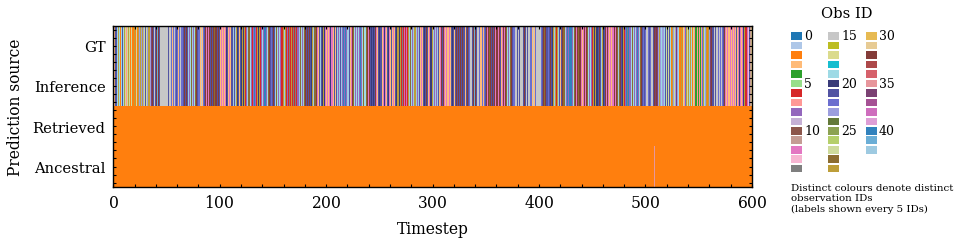


TEM v2 — arena_prediction_overlay (case=arena_n4)


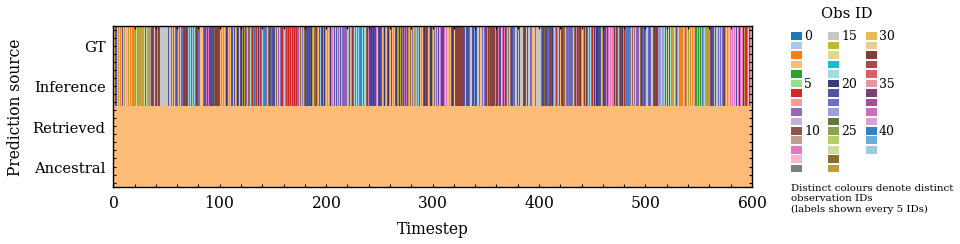


TEM v1: 8 overlay entries
  case=arena_n4 path=figures/0000-arena-test-0000-arena_prediction_overlay.png
  case=arena_n4 path=figures/0000-arena-test-0000-arena_prediction_overlay.pdf
  case=arena_n4 path=figures/0001-arena-test-0001-arena_prediction_overlay.png
  case=arena_n4 path=figures/0001-arena-test-0001-arena_prediction_overlay.pdf
  case=arena_n4 path=figures/0002-arena-test-0002-arena_prediction_overlay.png
  case=arena_n4 path=figures/0002-arena-test-0002-arena_prediction_overlay.pdf
  case=arena_n4 path=figures/0003-arena-test-0003-arena_prediction_overlay.png
  case=arena_n4 path=figures/0003-arena-test-0003-arena_prediction_overlay.pdf
TEM v2: 8 overlay entries
  case=arena_n4 path=figures/0000-arena-test-0000-arena_prediction_overlay.png
  case=arena_n4 path=figures/0000-arena-test-0000-arena_prediction_overlay.pdf
  case=arena_n4 path=figures/0001-arena-test-0001-arena_prediction_overlay.png
  case=arena_n4 path=figures/0001-arena-test-0001-arena_prediction_overlay.pdf

In [34]:
# --- Prediction overlay: first case from TEM v1 ---
overlay_entry = primary_report.figure_entry("arena_prediction_overlay", preferred_format="png")
if overlay_entry:
    abs_path = primary_report.root / overlay_entry.path
    print(f"TEM v1 — {overlay_entry.figure_id} (case={overlay_entry.regime_id})")
    ipy_display(Image(filename=str(abs_path)))
else:
    print("No arena_prediction_overlay found in TEM v1 ReportRun.")

print()

# --- Prediction overlay: first case from TEM v2 ---
overlay_entry_v2 = diagnostic_report.figure_entry("arena_prediction_overlay", preferred_format="png")
if overlay_entry_v2:
    abs_path_v2 = diagnostic_report.root / overlay_entry_v2.path
    print(f"TEM v2 — {overlay_entry_v2.figure_id} (case={overlay_entry_v2.regime_id})")
    ipy_display(Image(filename=str(abs_path_v2)))
else:
    print("No arena_prediction_overlay found in TEM v2 ReportRun.")

# --- List all overlay entries from both reports ---
print()
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    fig_index = report.figures()
    if fig_index:
        overlays = [e for e in fig_index.entries if e.figure_id == "arena_prediction_overlay"]
        print(f"{label}: {len(overlays)} overlay entries")
        for e in overlays:
            print(f"  case={e.regime_id} path={e.path}")
    else:
        print(f"{label}: no figure index")

### MEC / HPC Representational Diagnostics

The ReportRuns now include `mec_cells` and `hpc_cells` figures — spatial rate
maps and autocorrelograms for TEM's MEC-like (`g`) and HPC-like (`p`) latent
states.  These are **representational diagnostics**, not quantitative evidence.

**What this shows:**
- MEC cells: rate maps (top row) and 2-D spatial autocorrelograms (bottom row)
  for selected `g` units at frequency 0.
- HPC cells: same layout for `p` units — rate maps showing spatially localised
  activity and autocorrelograms showing spatial periodicity.

**What this does not show:**
- Gridness scores or shuffle baselines for MEC cells (pending).
- Spatial information ranking or significance thresholds for HPC cells.
- A quantitative comparison across models or environments.
- These figures provide visual evidence about spatial structure in `g` and `p`,
  but do **not** yet establish place-cell or grid-cell claims quantitatively.

Below are the first-case `mec_cells` and `hpc_cells` figures from each
ReportRun.

TEM v1 — mec_cells (case=arena_n4)


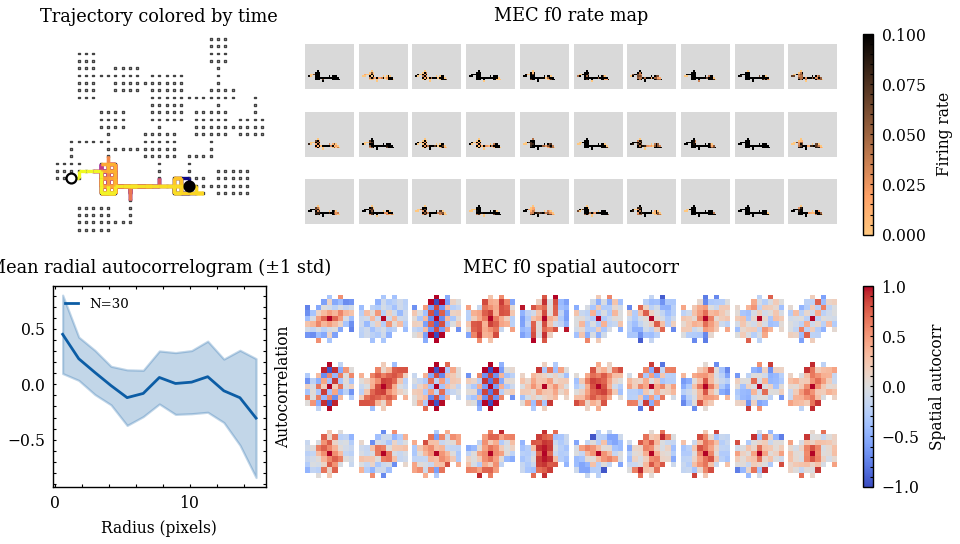


TEM v2 — mec_cells (case=arena_n4)


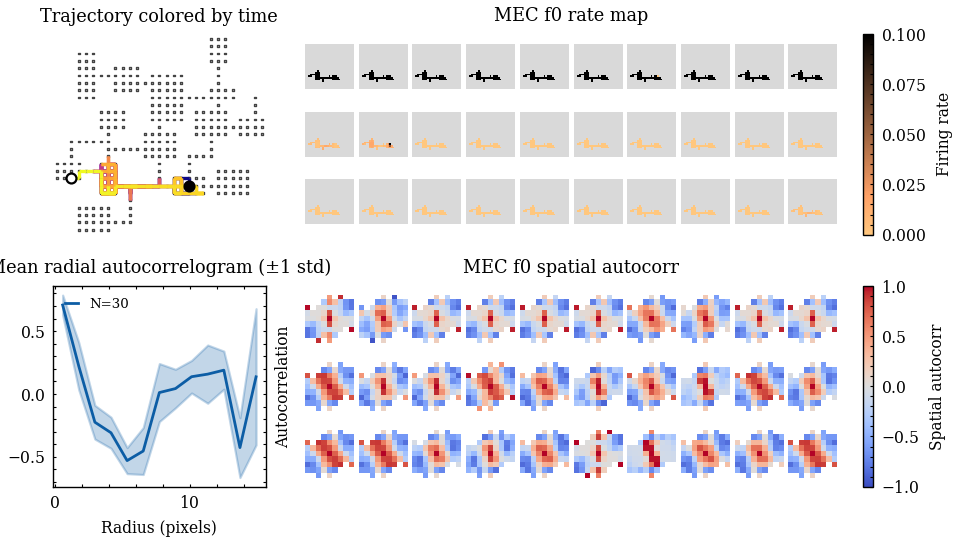


TEM v1 — hpc_cells (case=arena_n4)


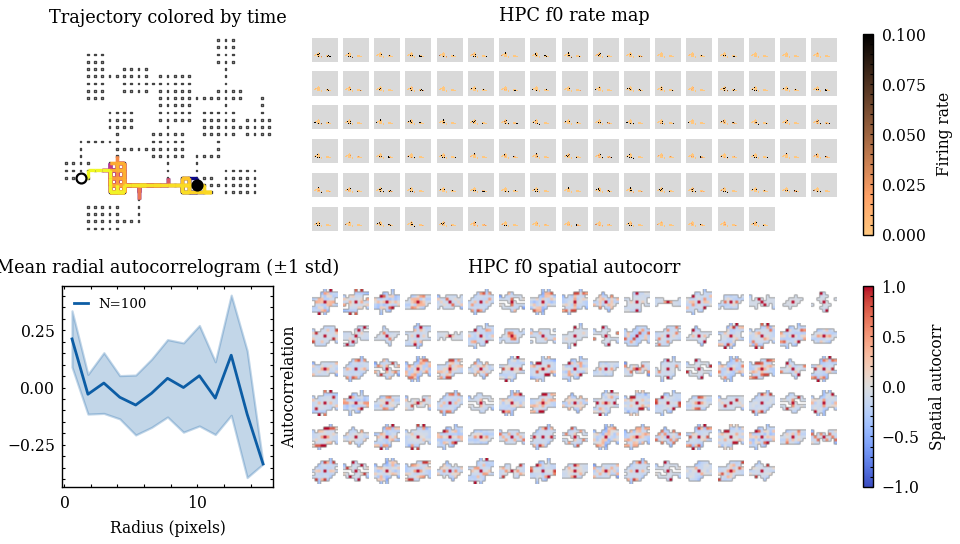


TEM v2 — hpc_cells (case=arena_n4)


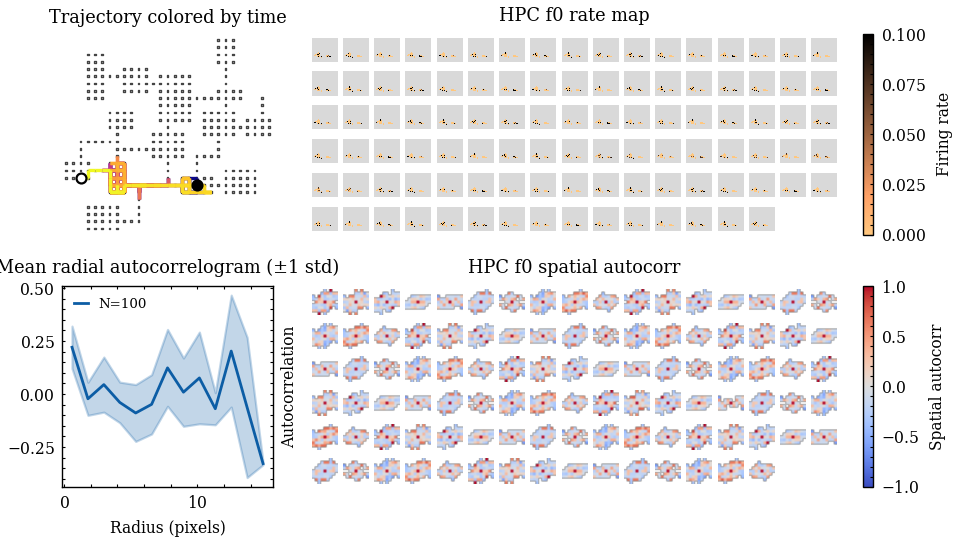

In [35]:
# --- mec_cells figure: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("mec_cells", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        ipy_display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_cells not available.")
    print()

# --- hpc_cells figure: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("hpc_cells", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        ipy_display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_cells not available.")
    print()

## 8. What Would Count as Structural-Memory Evidence?

The Whittington-style TEM claim requires evidence at multiple levels beyond
simple observation reconstruction.  The table below defines what would
constitute supporting evidence for each sub-claim, which latent variable
would be inspected, and what artifact type is required.

| Claim | Variable | Required Evidence | Figure / Artifact Type |
|---|---|---|---|
| Structural state encodes topology | `g` (MEC) | `g` distances correlate with graph distances; position decodable from `g` | PCA/UMAP coloured by position; distance-vs-graph-distance scatter |
| Sensory/content factorization | `x` (HPC) | `x` clusters by observation ID, not position; `x` separable from `g` | PCA/UMAP coloured by observation ID; confusion matrix |
| Path integration → place-like codes | `p` (HPC stage) | Units with spatially localised activity; above-chance spatial information | Spatial rate maps; spatial information score distribution |
| Grid-like periodic structure | `g` (MEC) | Autocorrelogram with 60°/120° peaks; gridness above shuffle | Rate maps + autocorrelograms; gridness vs shuffle |
| Memory retrieval supports revisits | Retrieved pathway | Retrieval accuracy higher on revisit steps than first-visit steps | Retrieval accuracy by step type; per-pathway revisit metrics |
| Structural generalisation | `g$ across envs | $g$ similarity preserved under sensory remapping | Cross-environment $g$ alignment; few-shot adaptation curves |

**None of these analyses are currently backed by ReportRun artifacts.**
Sections 9–10 summarise current status and next pipeline steps.

In [36]:
from ehc_sn.diagnostics import load_pathway_probe
import json
from pathlib import Path

# --- Pathway probe ---
probe_path = Path("artifacts/evaluation/tem_v1/diagnostics/pathway_probe.json")
if probe_path.exists():
    probe = load_pathway_probe(str(probe_path))

    print("### Pathway Contrast Ratios (TEM v1)")
    print("Ratio > 1.0 = pathway stronger than inference; near 0 = content loss.")
    print()

    stages = ["p_post", "HPC", "x (content)", "logits"]
    print(f"{'Stage':<20s} {'Retrieved/Inference':>22s} {'Ancestral/Inference':>22s}")
    print("-" * 64)
    for i, stage in enumerate(stages):
        if i < len(probe.contrast_inference_vs_retrieved):
            r = probe.contrast_inference_vs_retrieved[i]
            a = probe.contrast_inference_vs_ancestral[i]
            print(f"  {stage:<18s} {r:>22.4f} {a:>22.4f}")

    print()
    print("### Pathway Stage Metrics (TEM v1) — Norm / Effective Rank")
    print(f"{'Pathway':<15s} {'Stage':<20s} {'Norm (mean)':>14s} {'Eff. Rank':>12s}")
    print("-" * 65)
    for pathway_name, pathway_data in [
        ("inference", probe.inference),
        ("retrieved", probe.retrieved),
        ("ancestral", probe.ancestral),
    ]:
        for i, sm in enumerate(pathway_data):
            stage_label = stages[i] if i < len(stages) else f"stage_{i}"
            print(
                f"  {pathway_name:<13s} {stage_label:<20s} "
                f"{sm.norm_mean:>14.4f} {sm.effective_rank:>12.1f}"
            )

    print()
    print(f"Inference logit entropy:   {probe.logits_inference.entropy_mean:.3f}")
    print(f"Retrieved logit entropy:   {probe.logits_retrieved.entropy_mean:.3f}")
    print(f"Ancestral logit entropy:   {probe.logits_ancestral.entropy_mean:.3f}")
    print()
    print("⚠️  Pathway-probe argmax accuracy ≈ 0–1.3% disagrees with ReportRun 100%.")
    print("   Accuracy values are NOT presented as behavioral evidence.")
else:
    print("pathway_probe.json not found.")

print()

# --- Memory probe ---
mem_path = Path("artifacts/evaluation/tem_v1/diagnostics/memory_probe.json")
if mem_path.exists():
    mem = json.loads(mem_path.read_text(encoding="utf-8"))
    sr = mem["self_retrieval"]
    ms = mem["memory_stats"]

    print("### Memory Self-Retrieval Statistics (TEM v1)")
    print(f"  Nearest-neighbour accuracy:           {sr['nn_accuracy']:.4f}")
    print(f"  Top-5 retrieval accuracy:             {sr['top5_accuracy']:.4f}")
    print(f"  Top-10 retrieval accuracy:            {sr['top10_accuracy']:.4f}")
    print(f"  NN same-position fraction:            {sr['nn_same_position_fraction']:.4f}")
    print(f"  NN same-observation fraction:         {sr['nn_same_observation_fraction']:.4f}")
    print(f"  NN GT observation accuracy:           {sr['nn_gt_observation_accuracy']:.4f}")
    print(f"  NN temporal distance (mean):          {sr['nn_temporal_distance_mean']:.1f} steps")
    print(f"  NN temporal distance (median):        {sr['nn_temporal_distance_median']:.1f} steps")
    print(f"  Cosine similarity (mean):             {sr['cosine_mean']:.4f}")
    print()
    print("  Memory bank stats:")
    print(f"    Memory norm:               {ms['memory_norm']:.4f}")
    print(f"    Memory effective rank:      {ms['memory_effective_rank']:.1f}")
    print(f"    Memory saturation fraction: {ms['memory_saturation_fraction']:.4f}")
else:
    print("memory_probe.json not found.")

### Pathway Contrast Ratios (TEM v1)
Ratio > 1.0 = pathway stronger than inference; near 0 = content loss.

Stage                   Retrieved/Inference    Ancestral/Inference
----------------------------------------------------------------
  p_post                             1.7164                 1.7844
  HPC                                1.9198                 1.9610
  x (content)                        1.9199                 1.9615
  logits                             1.9298                 1.9808

### Pathway Stage Metrics (TEM v1) — Norm / Effective Rank
Pathway         Stage                   Norm (mean)    Eff. Rank
-----------------------------------------------------------------
  inference     p_post                       0.3259         73.4
  inference     HPC                          0.6431          9.9
  inference     x (content)                  0.6430          9.3
  inference     logits                       2.7594          9.3
  retrieved     p_post                   

## 9. Current Structural-Memory Evidence Status

| Claim | Current Status | Blocking Gap |
|---|---|---|
| `g` encodes topology | ❌ Not evaluated | `g` geometry (PCA/UMAP, distance correlation) not yet implemented |
| `x` / `g` factorization | ❌ Not evaluated | `x` content embedding not yet implemented |
| Place-like `p` | ⚠️ Qualitative (§7) | `hpc_cells` rate maps visible but no spatial information scores |
| Grid-like `g` | ⚠️ Qualitative (§7) | `mec_cells` autocorrelograms visible but no gridness scores |
| Memory retrieval | ⚠️ Diagnostic only (§11) | Memory probe not integrated into ReportRun; pathway probe has eval-parity issue |
| Remapping / generalisation | ❌ Not evaluated | No remapping dataset variant exists |
| TEM v2 vs TEM v1 | ❌ Not evaluated | Both at ceiling on $n=4$; larger benchmark needed |

**Key statement:** The only structural-memory-adjacent evidence currently
backed by ReportRun artifacts is bounded behavioral reconstruction (§6) and
qualitative representational diagnostics (§7).  Quantitative latent-variable,
retrieval-pathway, and remapping claims require additional pipeline
development (§10).

## 10. Representation Analyses Needed Next

The analyses defined in §8 require the report figure-generation pipeline to
extract latent activations from evaluation traces and render standard
diagnostics.  This is the next engineering milestone, not a scientific one.

### Current Pipeline Status

**MEC/HPC representational figures** (`mec_cells`, `hpc_cells`): ✅ Figure
templates exist, are registered for report use, and are now rendered in
TEM v1 and TEM v2 Arena-Struct ReportRuns.  The notebook displays them in
§7 with conservative captions.

### Pipeline Tasks (in priority order)

1. **`g` geometry figure:** Extract `g` activations from `.dense.npz` traces;
   render PCA/UMAP coloured by position + distance-correlation scatter.
2. **`x` content figure:** Extract `x` activations; render PCA/UMAP coloured
   by observation ID + confusion matrix.
3. **Gridness scores for `g`:** Add quantitative gridness scores and shuffle
   baselines to the `mec_cells` figure.
4. **Spatial information for `p`:** Rank HPC units by spatial information;
   add significance thresholds to `hpc_cells`.
5. **Pathway-stratified metrics:** Aggregate per-step
   `TEM_ACC_OBS_{INFERENCE,RETRIEVED,ANCESTRAL}_ALL` numerators/denominators
   into ReportRun metric records (unblocks revisit-pathway comparison).
6. **Failure rollouts:** Identify worst episodes by prediction error; render
   overlay panels with error markers.

Until all artifacts are produced by the reporting pipeline and surfaced as
ReportRun figures/metrics, the structural-memory claim remains unevaluated.

## 11. Diagnostic Appendix: TEM v1 Memory/Pathway Probes

> **This appendix presents development diagnostics, not primary report
> evidence.**  These probes have not been validated against the evaluation
> execution path and are not part of the ReportRun metric/figure schema.

### Memory Probe

The memory probe (`artifacts/evaluation/tem_v1/diagnostics/memory_probe.json`)
measures self-retrieval quality — when the model queries its own memory
bank, does it retrieve content-consistent and position-consistent states?

**Interpretation (diagnostic only):**
- `nn_same_position_fraction = 0.875`: 87.5% of nearest-neighbour retrievals
  point to the same arena position.  The memory bank preserves spatial
  structure.
- `nn_same_observation_fraction = 0.990`: 99% of NN retrievals point to the
  same observation class.  Memory retrieval is content-consistent.
- `top5_accuracy = 0.870`, `top10_accuracy = 0.935`: Retrieval is not
  perfect at rank 1 (0.438) but strong in top-k.
- `memory_saturation_fraction = 0.0`: Memory bank is not saturated
  (capacity 1024, likely $\ll$ 1024 entries stored).

These values are consistent with a functional, non-saturated memory system,
but they have **not** been validated against a retrieval-shuffle baseline
and are **not** integrated into the ReportRun evidence schema.

### Pathway Probe

The pathway probe (`artifacts/evaluation/tem_v1/diagnostics/pathway_probe.json`)
extracts per-stage metrics for the inference, retrieved, and ancestral
pathways.

**⚠️ Critical caveat:** The pathway-probe argmax accuracy (≈0–1.3%)
disagrees with the ReportRun's `accuracy_all = 1.0`.  This discrepancy
indicates that the probe's decoder path differs from the evaluation
execution path.  **Pathway-probe accuracy values must not be used as
behavioral evidence.**  The contrast ratios and stage-level metrics (norm,
effective rank) are presented for qualitative inspection only.

The code cell below loads and displays both probes.

## 12. Evidence Summary

| Claim | Status | Reason |
|---|---|---|
| TEM v1 reconstructs bounded Arena slice | ✅ Supported | ReportRun metrics; `accuracy_revisit = 1.0` |
| TEM v2 reconstructs bounded Arena slice | ✅ Supported | ReportRun metrics; `accuracy_revisit = 1.0` |
| TEM v2 improves over TEM v1 | ❌ Not evaluated | $n=4$ ceiling; both models indistinguishable |
| Structural `g` learned | ⚠️ Qualitative | ReportRun-backed `mec_cells` figures available (§7); no quantitative gridness |
| Place-like `p` learned | ⚠️ Qualitative | ReportRun-backed `hpc_cells` figures available (§7); no spatial information scores |
| Grid-like `g` learned | ❌ Not evaluated | Autocorrelograms visible but no gridness / shuffle baseline |
| Memory retrieval coherent | ⚠️ Diagnostic support only | Memory probe (§11); no shuffle baseline |
| Retrieved/ancestral pathway behaviour explained | ❌ Not concluded | Pathway probe (§11) has eval-parity issue |
| Remapping / generalisation | ❌ Not evaluated | No cross-environment evidence |

**Bottom line:** TEM v1 and TEM v2 solve bounded Arena reconstruction at
$n=4$.  MEC/HPC representational diagnostics are now available as ReportRun
figures but remain qualitative.  The structural-memory claim — that the model
learns reusable relational structure separable from sensory content — is
**not yet fully evaluated** with quantitative ReportRun-backed evidence.

## 13. Reproducibility

### Artifact Paths

| Artifact | Path |
|---|---|
| TEM v1 ReportRun | `artifacts/reports/tem_v1/arena_n4` |
| TEM v2 ReportRun | `artifacts/reports/tem_v2/arena_n4` |
| TEM v1 eval artifacts | `artifacts/evaluation/tem_v1/arena_n4` |
| TEM v2 eval artifacts | `artifacts/evaluation/tem_v2/arena_n4` |
| TEM v1 diagnostic probes | `artifacts/evaluation/tem_v1/diagnostics/` |
| TEM v1 checkpoint | `checkpoints/tem-v1/eval-weights-only.pt` (from `tem-v1-step=00010000.ckpt`) |
| TEM v2 checkpoint | `checkpoints/tem-v2/eval-weights-only.pt` (from `tem-v2-step=00010000.ckpt`) |
| TEM v1 model config | `config/models/tem-v1-base.toml` |
| TEM v2 model config | `config/models/tem-v2-base.toml` |
| TEM v1 report spec | `config/reporting/tem_v1_arena_n4.toml` |
| TEM v2 report spec | `config/reporting/tem_v2_arena_n4.toml` |
| TEM v1 eval config | `config/evaluation/tem-v1-arena.toml` |
| Arena-Struct benchmark spec | `spec/spec-benchmark-suite.md` §6.1 |

### Commands to Reproduce

```bash
# Generate evaluation artifacts
python scripts/evaluation/run_eval.py \
    --model-family tem-v1 \
    --checkpoint checkpoints/tem-v1/eval-weights-only.pt \
    --config config/evaluation/tem-v1-arena.toml \
    --task arena \
    --provider-ref ehc_sn.tasks.arena.providers.ArenaReplayProvider

# Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/tem_v1_arena_n4.toml
```

### Known Reproducibility Gaps

| Gap | Impact |
|---|---|
| Git commit SHA not recorded | Cannot pin the exact code version |
| Checkpoint SHA256 not recorded | Cannot verify checkpoint integrity |
| Random seed not recorded | Cannot reproduce stochastic elements |
| Training logs not ingested | No training curves available in this report |
| Pathway probe / eval accuracy discrepancy | Probe decoder path not validated against evaluation path |
| EHC v1 / EHC v2 checkpoints | Not yet trained; structural-memory comparison incomplete |